# 5. One qubit

Notebook 4 replaced wavefunctions with columns of amplitudes and operators with
matrices. Take that picture and keep only **two** levels. What is left is a qubit,
and it is the simplest non-trivial quantum system there is -- simpler than
anything in notebooks 2 to 4, because the state space is two complex numbers and
nothing more.

Physically it is not a toy. An electron's spin, a photon's polarization, the two
lowest levels of a superconducting circuit, or two levels of an atom that a laser
addresses while the rest stay out of the way -- all the same two-dimensional
mathematics.

In [1]:
(define (eye n) (m:generate n n (lambda (i j) (if (= i j) 1 0))))
(define (dagger M) (m:transpose ((m:elementwise conjugate) M)))
(define (commutator A B) (- (* A B) (* B A)))
(define (anticommutator A B) (+ (* A B) (* B A)))
(define (ket lst) (m:generate (length lst) 1 (lambda (i j) (list-ref lst i))))

eye 
dagger 
commutator 
anticommutator 
ket 

## 5.1 States

The two basis states are written $|0\rangle$ and $|1\rangle$. A general state is

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle,
\qquad |\alpha|^2 + |\beta|^2 = 1,$$

with $\alpha, \beta$ complex. `scmutils` writes the imaginary unit `+i`, so
`(* (/ 1 (sqrt 2)) (+ ket0 (* +i ket1)))` is a legitimate state.

In [2]:
(define ket0 (ket (list 1 0)))
(define ket1 (ket (list 0 1)))

(define (amplitude bra state) (ref (* (dagger bra) state) 0 0))
(define (probability bra state) (square (magnitude (amplitude bra state))))
(define (norm state) (real-part (ref (* (dagger state) state) 0 0)))

(define plus  (* (/ 1 (sqrt 2)) (+ ket0 ket1)))        ; |+>
(define plusi (* (/ 1 (sqrt 2)) (+ ket0 (* +i ket1)))) ; |+i>

(list 'norm-plus (norm plus)
      'norm-plusi (norm plusi)
      'plus-gives-0 (probability ket0 plus)
      'plusi-gives-0 (probability ket0 plusi)
      'plusi-gives-1 (probability ket1 plusi))

ket0 
ket1 
amplitude 
probability 
norm 
plus 
plusi 
#|
(norm-plus .9999999999999998
           norm-plusi
           .9999999999999998
           plus-gives-0
           .4999999999999999
           plusi-gives-0
           .4999999999999999
           plusi-gives-1
           .4999999999999999)
|#

Both are legal states, and both give 50/50 when measured in the
$\{|0\rangle, |1\rangle\}$ basis. **They are not the same state**, though: the
relative phase $i$ between the two amplitudes is physical, and section 5.5 shows
a measurement that tells them apart.

What is *not* physical is an overall phase. $|\psi\rangle$ and
$e^{i\varphi}|\psi\rangle$ predict identically everything, because the phase
cancels in $\langle\psi|A|\psi\rangle$. That is the same fact that made energy
eigenstates stationary in notebook 4.

## 5.2 The Pauli matrices

Every $2\times2$ Hermitian matrix is a real combination of the identity and the
three Pauli matrices, so these four are the entire observable vocabulary of one
qubit.

In [3]:
(define sx (matrix-by-rows (list 0  1) (list 1  0)))
(define sy (matrix-by-rows (list 0 -i) (list +i 0)))
(define sz (matrix-by-rows (list 1  0) (list 0 -1)))

sx 
sy 
sz 

Three facts define their algebra. Each squares to the identity; different ones
anticommute; and the product of two gives the third, times $i$.

In [4]:
(print-expression (* sx sx))

(matrix-by-rows (list 1 0) (list 0 1))

;No return value.

In [5]:
(print-expression (anticommutator sx sz))

(matrix-by-rows (list 0 0) (list 0 0))

;No return value.

In [6]:
(print-expression (- (* sx sy) (* +i sz)))

(matrix-by-rows (list 0 0) (list 0 0))

;No return value.

$\sigma_x^2 = I$; $\{\sigma_x,\sigma_z\} = 0$; and $\sigma_x\sigma_y = i\sigma_z$
exactly, since the difference is the zero matrix. Combining the last two,
$[\sigma_x,\sigma_y] = 2i\sigma_z$ -- the angular momentum algebra. A qubit *is*
a spin-$\tfrac12$.

Because $\sigma_z^2 = I$, its eigenvalues are $\pm 1$, with eigenvectors
$|0\rangle$ and $|1\rangle$. So "measuring $\sigma_z$" and "measuring which of
$|0\rangle,|1\rangle$" are the same operation, and $\langle\sigma_z\rangle$ runs
from $+1$ to $-1$.

## 5.3 The Bloch vector

The three expectation values

$$\vec r = \big(\langle\sigma_x\rangle,\ \langle\sigma_y\rangle,\
                \langle\sigma_z\rangle\big)$$

hold everything measurable about a qubit. For any state of the form we have been
writing, $|\vec r| = 1$: the states live on the surface of a sphere, the **Bloch
sphere**. $|0\rangle$ is the north pole, $|1\rangle$ the south, and the
superpositions sit around the equator.

In [7]:
(define (expectation A state) (real-part (ref (* (dagger state) A state) 0 0)))

(define (bloch state)
  (list (expectation sx state) (expectation sy state) (expectation sz state)))

(define (bloch-length state)
  (sqrt (apply + (map square (bloch state)))))

(list 'ket0  (bloch ket0)
      'ket1  (bloch ket1)
      'plus  (bloch plus)
      'plusi (bloch plusi)
      'lengths (map bloch-length (list ket0 ket1 plus plusi)))

expectation 
bloch 
bloch-length 
#|
(ket0 (0 0 1)
      ket1
      (0 0 -1)
      plus
      (.9999999999999998 0 0.)
      plusi
      (0 .9999999999999998 0.)
      lengths
      (1 1 .9999999999999998 .9999999999999998))
|#

There is the difference between $|+\rangle$ and $|+i\rangle$, made concrete:
both sit on the equator ($\langle\sigma_z\rangle = 0$, hence the 50/50), but one
points along $x$ and the other along $y$. The relative phase is an *angle* around
the equator. All four vectors have length 1.

A length below 1 would mean a **mixed** state -- a classical probabilistic mixture
rather than a superposition. Notebook 6 produces one by ignoring half of an
entangled pair.

## 5.4 Gates

A gate is a unitary matrix, $U^\dagger U = I$. Unitarity is exactly the condition
that probability is preserved.

In [8]:
(define gate-X sx)                                              ; bit flip
(define gate-Z sz)                                              ; phase flip
(define gate-H (* (/ 1 (sqrt 2)) (matrix-by-rows (list 1 1) (list 1 -1))))
(define gate-S (matrix-by-rows (list 1 0) (list 0 +i)))         ; quarter turn

(define (unitary? U) (print-expression (- (* (dagger U) U) (eye 2))))
(unitary? gate-H)

gate-X 
gate-Z 
gate-H 
gate-S 
unitary? 
(matrix-by-rows (list -2.220446049250313e-16 0.)
                (list 0. -2.220446049250313e-16))

;No return value.

Zero to machine precision, so $H$ is unitary. The **Hadamard** gate is the one
that creates superposition: it sends $|0\rangle$ to $|+\rangle$, which is how
every quantum algorithm starts.

In [9]:
(list 'H-on-0 (bloch (* gate-H ket0))
      'H-twice (probability ket0 (* gate-H gate-H ket0))
      'X-on-0 (probability ket1 (* gate-X ket0))
      'S-on-plus (bloch (* gate-S plus)))

#|
(H-on-0 (.9999999999999998 0 0.)
        H-twice
        .9999999999999996
        X-on-0
        1
        S-on-plus
        (0 .9999999999999998 0.))
|#

$H|0\rangle$ points along $+x$; applying $H$ twice returns to $|0\rangle$ with
certainty, since $H^2 = I$. $X$ flips $|0\rangle$ to $|1\rangle$. And $S$ takes
$|+\rangle$ (along $x$) to $|+i\rangle$ (along $y$) -- a quarter turn about the
$z$ axis, which is what a relative phase of $i$ means geometrically.

## 5.5 Every gate is a rotation

Any single-qubit unitary is a rotation of the Bloch sphere by an angle $\theta$
about an axis $\hat n$:

$$U = e^{-i\theta\,\hat n\cdot\vec\sigma/2}
    = \cos\tfrac{\theta}{2}\,I - i\sin\tfrac{\theta}{2}\,\hat n\cdot\vec\sigma .$$

The closed form on the right follows from $(\hat n\cdot\vec\sigma)^2 = I$, which
collapses the exponential series into a cosine and a sine. Rather than take that
on trust, compare it against the series summed term by term.

In [10]:
(define (rot-axis nx ny nz theta)
  (- (* (cos (/ theta 2)) (eye 2))
     (* +i (sin (/ theta 2)) (+ (* nx sx) (* ny sy) (* nz sz)))))

;; exp(M) by its Taylor series, for comparison only.
(define (mat-exp M terms)
  (let loop ((k 0) (term (eye 2)) (acc (* 0 (eye 2))))
    (if (> k terms) acc (loop (+ k 1) (* (/ 1 (+ k 1)) term M) (+ acc term)))))

(print-expression
  (- (rot-axis 1 0 0 .7)                    ; closed form, theta = 0.7 about x
     (mat-exp (* -1 +i .35 sx) 25)))        ; exp(-i (theta/2) sigma_x)

rot-axis 
mat-exp 
(matrix-by-rows (list -1.1102230246251565e-16 -5.551115123125783e-17i)
                (list -5.551115123125783e-17i -1.1102230246251565e-16))

;No return value.

Agreement to $10^{-16}$. With this one procedure every gate above is a special
case: $X$ is a half turn about $x$ (up to phase), $Z$ a half turn about $z$, $S$ a
quarter turn about $z$, and $H$ a half turn about the diagonal axis
$(\hat x + \hat z)/\sqrt2$.

## 5.6 Rabi oscillations

Now some physics. Shine a resonant field on a two-level atom and the Hamiltonian
is $\hat H = \tfrac{\hbar\Omega}{2}\sigma_x$, where $\Omega$ is the Rabi
frequency. Evolution is $e^{-i\hat Ht/\hbar}$, which by section 5.5 is a rotation
about $x$ at rate $\Omega$. Start in $|0\rangle$ and the population sloshes back
and forth.

If the field is *detuned* from resonance by $\Delta$, a $\sigma_z$ term joins in:

$$\hat H = \frac{\hbar}{2}\left(\Delta\,\sigma_z + \Omega\,\sigma_x\right),$$

tilting the rotation axis away from $x$. Set $\hbar = 1$ and $\Omega = 1$.

In [11]:
(define (u-rabi delta omega t)
  (let ((lam (sqrt (+ (square delta) (square omega)))))    ; generalized Rabi freq
    (rot-axis (/ omega lam) 0 (/ delta lam) (* lam t))))

(define (p-excited delta t) (probability ket1 (* (u-rabi delta 1. t) ket0)))

;; Closed form: (Omega^2 / Lambda^2) sin^2(Lambda t / 2).
(define (p-theory delta t)
  (let ((lam2 (+ (square delta) 1.)))
    (* (/ 1. lam2) (square (sin (* (sqrt lam2) t 1/2))))))

(map (lambda (d) (list 'detuning d 'simulated (p-excited d 1.7) 'closed-form (p-theory d 1.7)))
     (list 0. 1. 2.))

u-rabi 
p-excited 
p-theory 
#|
((detuning 0. simulated .5644222471477623 closed-form .5644222471477623)
 (detuning 1. simulated .435049827149849 closed-form .4350498271498491)
 (detuning 2. simulated .17901620908441745 closed-form .17901620908441745))
|#

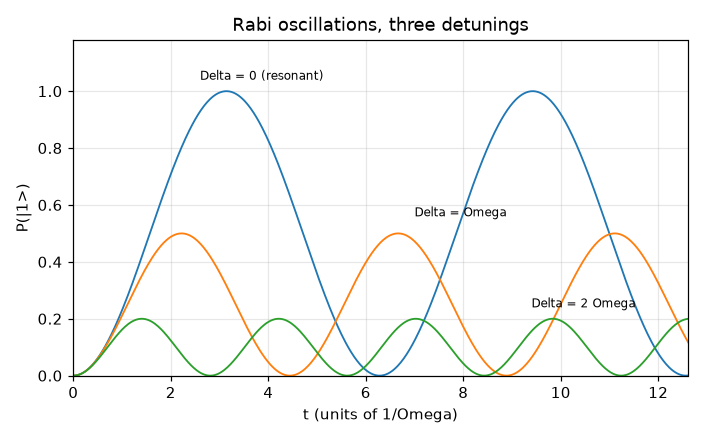

In [12]:
%%plot --title "Rabi oscillations, three detunings" --xlabel "t (units of 1/Omega)" --ylabel "P(|1>)" --grid
(define win (frame 0. 12.6 0. 1.18))
(plot-function win (lambda (t) (p-excited 0. t)) 0. 12.6 .02)
(plot-function win (lambda (t) (p-excited 1. t)) 0. 12.6 .02)
(plot-function win (lambda (t) (p-excited 2. t)) 0. 12.6 .02)
(graphics-draw-text win 2.6 1.04 "Delta = 0 (resonant)")
(graphics-draw-text win 7.0 .56 "Delta = Omega")
(graphics-draw-text win 9.4 .24 "Delta = 2 Omega")

On resonance the atom is driven all the way to $|1\rangle$ and back: at
$t = \pi/\Omega$ the transfer is complete. That is a **$\pi$ pulse**, the way a
bit is flipped in a real machine, and it is the same object as the $X$ gate.
Halfway there, at $t = \pi/2\Omega$, is a $\pi/2$ pulse, which makes an equal
superposition -- a Hadamard, near enough.

Detuning does two things at once, both visible: the oscillation gets **faster**
(rate $\sqrt{\Delta^2+\Omega^2}$) and **shallower** (peak
$\Omega^2/(\Delta^2+\Omega^2)$). Off resonance you cannot flip the qubit however
long you wait. That is why gates need accurate frequencies.

## 5.7 The same motion on the Bloch sphere

The resonant drive rotates $\vec r$ about the $x$ axis, so the tip travels a great
circle in the $y$-$z$ plane. Plotting $\langle\sigma_z\rangle$ against
$\langle\sigma_y\rangle$ should give a circle of radius 1; with detuning the axis
tilts and the circle becomes a smaller one traced on the sphere.

In [13]:
;; Draw a curve through a list of points. plot-xy and plot-parametric scatter
;; dots, all in one colour; successive plot-line segments make a real polyline
;; and each polyline gets its own colour.
(define (plot-data win xs ys)
  (let loop ((xs xs) (ys ys))
    (if (and (pair? (cdr xs)) (pair? (cdr ys)))
        (begin (plot-line win (car xs) (car ys) (cadr xs) (cadr ys))
               (loop (cdr xs) (cdr ys))))))

;; The Bloch vector of |0> driven at detuning delta, sampled over one full turn.
(define (bloch-track delta)
  (let* ((lam (sqrt (+ (square delta) 1.)))
         (ts  (iota 300 0. (/ 6.2832 lam 299.))))
    (map (lambda (t) (bloch (* (u-rabi delta 1. t) ket0))) ts)))

plot-data 
bloch-track 

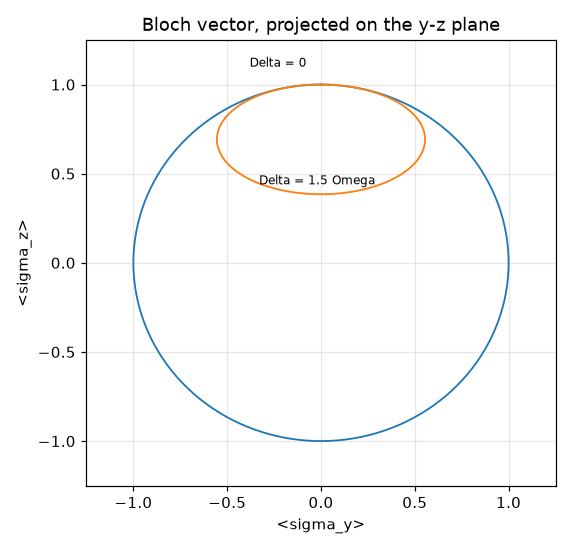

In [14]:
%%plot --title "Bloch vector, projected on the y-z plane" --xlabel "<sigma_y>" --ylabel "<sigma_z>" --grid --width 5.2 --height 5.
(define win (frame -1.25 1.25 -1.25 1.25))
(for-each (lambda (delta)
            (let ((track (bloch-track delta)))
              (plot-data win (map cadr track) (map caddr track))))
          (list 0. 1.5))
(graphics-draw-text win -.38 1.1 "Delta = 0")
(graphics-draw-text win -.33 .44 "Delta = 1.5 Omega")

The resonant trajectory is the full great circle, reaching the south pole
($\langle\sigma_z\rangle = -1$, meaning $|1\rangle$ with certainty). The detuned
one is a smaller circle that never gets there -- exactly the reduced peak of the
previous figure, seen from the side.

## What to carry forward

- A qubit is two complex amplitudes; overall phase is nothing, relative phase is
  everything.
- $\langle\sigma_x\rangle, \langle\sigma_y\rangle, \langle\sigma_z\rangle$ is the
  Bloch vector; pure states have length 1.
- Gates are unitary, and every one-qubit gate is a rotation of that sphere.
- Driving a two-level atom *is* applying gates: a $\pi$ pulse is an $X$.

Everything so far, all five notebooks, has been one particle or one qubit at a
time. Next: [two qubits](06-two-qubits-and-entanglement.ipynb), where something
genuinely new appears.